Import Libraries

In [ ]:
#Download and install this (official Microsoft):

''' https://aka.ms/vs/17/release/vc_redist.x64.exe

After install → Restart PC '''

#-----uninstall old version-----
#pip uninstall -y tensorflow tensorflow-intel keras numpy protobuf

# -------Create new Virtual environment-----
''' python -m venv ml_env
ml_env\Scripts\activate '''

# pip install  opencv-python matplotlib gTTS playsound
#pip install numpy==1.26.4
#pip install protobuf==3.20.3
#pip install tensorflow==2.13.0

#------Checking numpy and tensorflow versions------
# python -c "import numpy; import tensorflow; 
# print(numpy.__version__, tensorflow.__version__)"


' python -m venv ml_env\nml_env\\Scripts\x07ctivate '

In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# ==========================
# Paths
# ==========================
train_dir = "../Datasets/Animals/train"
test_dir = "../Datasets/Animals/test"

img_size = 224
batch_size = 32
epochs = 10

# ==========================
# Data Generator
# ==========================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    
    brightness_range=[0.8,1.2],
    shear_range=0.15
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

# ==========================
# Load MobileNetV2
# ==========================
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(img_size, img_size, 3))

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================
# Train Model
# ==========================
history = model.fit(train_data, epochs=epochs, validation_data=test_data)

# ==========================
# Evaluate Accuracy
# ==========================
loss, acc = model.evaluate(test_data)
print(f"Model Accuracy: {acc*100:.2f}%")

# ==========================
# Save Model
# ==========================
model.save("../Save_Model/animal_model.h5")
print("Model saved!")


Found 7382 images belonging to 15 classes.
Found 899 images belonging to 15 classes.
Classes: ['Armadilles', 'Bear', 'Birds', 'Cow', 'Crocodile', 'Deer', 'Elephant', 'Goat', 'Horse', 'Jaguar', 'Monkey', 'Rabbit', 'Skunk', 'Tiger', 'Wild Boar']
Epoch 1/10
231/231 [==============================] - 201s 856ms/step - loss: 0.6412 - accuracy: 0.8220 - val_loss: 0.2280 - val_accuracy: 0.9310
Epoch 2/10
231/231 [==============================] - 220s 951ms/step - loss: 0.2438 - accuracy: 0.9218 - val_loss: 0.2002 - val_accuracy: 0.9377
Epoch 3/10
231/231 [==============================] - 215s 930ms/step - loss: 0.1823 - accuracy: 0.9419 - val_loss: 0.1923 - val_accuracy: 0.9422
Epoch 4/10
231/231 [==============================] - 239s 1s/step - loss: 0.1678 - accuracy: 0.9478 - val_loss: 0.1944 - val_accuracy: 0.9410
Epoch 5/10
231/231 [==============================] - 292s 1s/step - loss: 0.1545 - accuracy: 0.9512 - val_loss: 0.1793 - val_accuracy: 0.9488
Epoch 6/10
231/231 [============

Single Image Prediction

1/1 [==============================] - 0s 109ms/step
Predicted Animal: Goat
Confidence: 99.86%


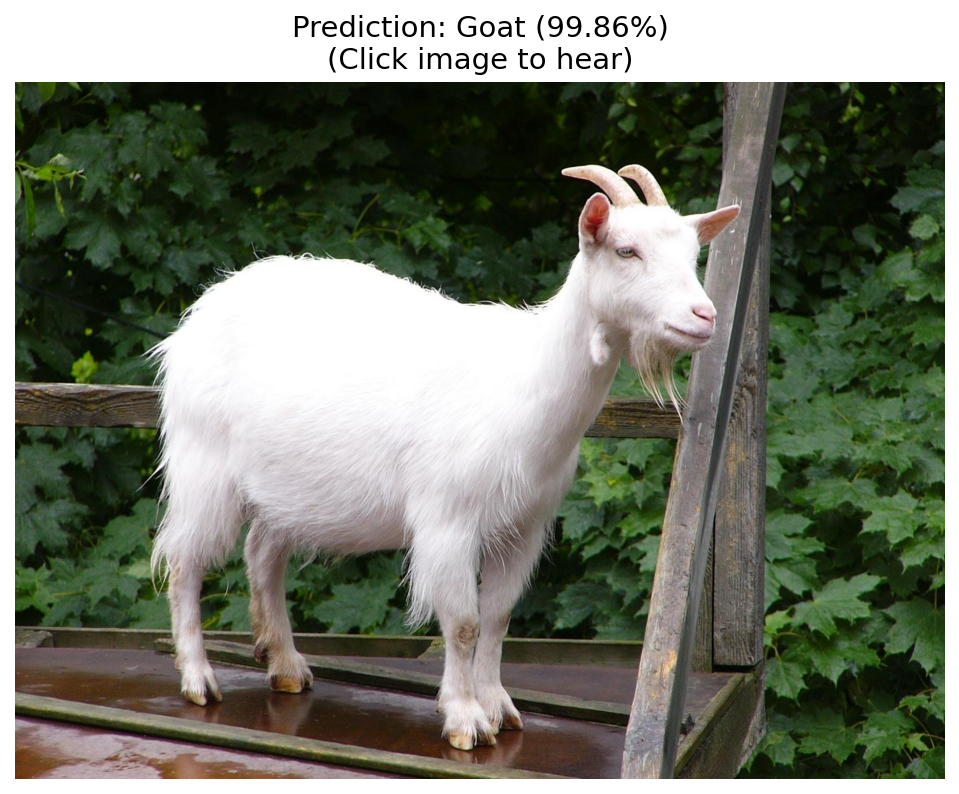

In [14]:
import cv2
import numpy as np
from gtts import gTTS
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# ==========================
# Predict New Image
# ==========================
img_path = "../Images/animal_data/goat.jpg"

# Read original image (HD)
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Resize ONLY for model
img_resized = cv2.resize(img_rgb, (img_size, img_size))
img_norm = img_resized / 255.0
img_input = np.expand_dims(img_norm, axis=0)

pred = model.predict(img_input)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print(f"Predicted Animal: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

# ==========================
# Text to Speech
# ==========================
text = f"This is a {pred_class}"
tts = gTTS(text=text, lang="en")
audio_path = "../Output_Audios/prediction.mp3"
tts.save(audio_path)

# ==========================
# Play audio on image click
# ==========================
def on_click(event):
    if event.inaxes:  # only when clicking on image
        display(Audio(audio_path, autoplay=True))

# ==========================
# Display HD Image
# ==========================
fig, ax = plt.subplots(figsize=(8,8), dpi=150)
ax.imshow(img_rgb)
ax.axis("off")
ax.set_title(
    f"Prediction: {pred_class} ({confidence:.2f}%)\n(Click image to hear)",
    fontsize=14
)

fig.canvas.mpl_connect("button_press_event", on_click)

plt.show()


Image Prediction for Unseen Data

In [15]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio, display
import ipywidgets as widgets

class_names = list(train_data.class_indices.keys())

def predict_image(img_path):
    # Load original image for display (HD)
    img_display = image.load_img(img_path)

    # Resize only for model
    img = image.load_img(img_path, target_size=(224,224))
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr, verbose=0)
    idx = np.argmax(preds)

    return img_display, class_names[idx], preds[0][idx]*100


def speak(text):
    tts = gTTS(text=f"This is a {text}", lang="en")
    audio_path = "../Output_Audios/mobilenetv2_audio1.mp3"
    tts.save(audio_path)
    display(Audio(audio_path, autoplay=True))


image_files = os.listdir("../Images/animal_data")
index = 0

output = widgets.Output()

current_label = ""  # store current prediction

def show_image(i):
    global current_label
    output.clear_output()
    img_path = os.path.join("../Images/animal_data", image_files[i])

    img, label, acc = predict_image(img_path)
    current_label = label

    with output:
        fig, ax = plt.subplots(figsize=(7,7), dpi=150)  # HD display
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{label} ({acc:.2f}%)\n(Click image to hear)", fontsize=13)

        # Click event
        def on_click(event):
            speak(current_label)

        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()


def next_img(b):
    global index
    index = (index + 1) % len(image_files)
    show_image(index)

def prev_img(b):
    global index
    index = (index - 1) % len(image_files)
    show_image(index)


btn_next = widgets.Button(description="⏭️ Next")
btn_prev = widgets.Button(description="⏮️ Previous")

btn_next.on_click(next_img)
btn_prev.on_click(prev_img)

display(widgets.HBox([btn_prev, btn_next]))
display(output)

show_image(index)


Output()

Another way

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# Paths
# ==========================
train_dir = "../Datasets/Animals/train"
test_dir = "../Datasets/Animals/test"

img_size = 224
batch_size = 32
epochs = 5   # max epochs (early stopping will stop earlier)

# ==========================
# Data Generator (Improved Augmentation)
# ==========================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.15
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

# ==========================
# Load MobileNetV2 (Transfer Learning)
# ==========================
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(img_size, img_size, 3))

base_model.trainable = False  # freeze first

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================
# Early Stopping
# ==========================
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

# ==========================
# Train Model (Stage 1)
# ==========================
history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=test_data,
    callbacks=[early_stop]
)

# ==========================
# Fine Tuning (Unfreeze last layers)
# ==========================
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data,
    callbacks=[early_stop]
)

# ==========================
# Evaluate Accuracy
# ==========================
loss, acc = model.evaluate(test_data)
print(f"Final Model Accuracy: {acc*100:.2f}%")

# ==========================
# Save Model
# ==========================
model.save("../Save_Model/animal_model1.h5")
print("Model saved!")


Found 7382 images belonging to 15 classes.
Found 899 images belonging to 15 classes.
Classes: ['Armadilles', 'Bear', 'Birds', 'Cow', 'Crocodile', 'Deer', 'Elephant', 'Goat', 'Horse', 'Jaguar', 'Monkey', 'Rabbit', 'Skunk', 'Tiger', 'Wild Boar']
Epoch 1/5
231/231 [==============================] - 474s 2s/step - loss: 0.6870 - accuracy: 0.8108 - val_loss: 0.2414 - val_accuracy: 0.9355
Epoch 2/5
231/231 [==============================] - 388s 2s/step - loss: 0.2535 - accuracy: 0.9251 - val_loss: 0.2129 - val_accuracy: 0.9366
Epoch 3/5
231/231 [==============================] - 438s 2s/step - loss: 0.2180 - accuracy: 0.9304 - val_loss: 0.2101 - val_accuracy: 0.9366
Epoch 4/5
231/231 [==============================] - 180s 778ms/step - loss: 0.1873 - accuracy: 0.9422 - val_loss: 0.2092 - val_accuracy: 0.9399
Epoch 5/5
231/231 [==============================] - 180s 779ms/step - loss: 0.1705 - accuracy: 0.9439 - val_loss: 0.1923 - val_accuracy: 0.9355
Epoch 1/5
231/231 [=====================

Single Image Prediction

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pyttsx3
import os

# --------------------------
# Image path
# --------------------------
img_path = "../Images/animal_data/goat2.jpg"

# --------------------------
# Read image
# --------------------------
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --------------------------
# Prepare image
# --------------------------
img_size = 128
img_resized = cv2.resize(img_rgb, (img_size, img_size))
img_norm = img_resized / 255.0
img_input = np.expand_dims(img_norm, axis=0)

# --------------------------
# Predict
# --------------------------
pred = model.predict(img_input, verbose=0)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("Predicted:", pred_class)
print(f"Confidence: {confidence:.2f}%")

# --------------------------
# Display image FIRST (non-blocking)
# --------------------------
plt.figure(figsize=(7,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.show(block=False)

# Give time for image to render
plt.pause(0.5)

# --------------------------
# SPEAK AFTER IMAGE IS SHOWN
# --------------------------
engine = pyttsx3.init()
engine.say(f"This is a {pred_class}")
engine.runAndWait()

# Keep window open
plt.pause(10)
plt.close()


error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


Image Prediction for Unseen data

In [ ]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio, display
import ipywidgets as widgets

class_names = list(train_data.class_indices.keys())

def predict_image(img_path):
    # Load original image for display (HD)
    img_display = image.load_img(img_path)

    # Resize only for model
    img = image.load_img(img_path, target_size=(224,224))
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr, verbose=0)
    idx = np.argmax(preds)

    return img_display, class_names[idx], preds[0][idx]*100


def speak(text):
    tts = gTTS(text=f"This is a {text}", lang="en")
    audio_path = "../Output_Audios/mobilenetv2_audio1.mp3"
    tts.save(audio_path)
    display(Audio(audio_path, autoplay=True))


image_files = os.listdir("../Images/animal_data")
index = 0

output = widgets.Output()

current_label = ""  # store current prediction

def show_image(i):
    global current_label
    output.clear_output()
    img_path = os.path.join("../Images/animal_data", image_files[i])

    img, label, acc = predict_image(img_path)
    current_label = label

    with output:
        fig, ax = plt.subplots(figsize=(7,7), dpi=150)  # HD display
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{label} ({acc:.2f}%)\n(Click image to hear)", fontsize=13)

        # Click event
        def on_click(event):
            speak(current_label)

        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()


def next_img(b):
    global index
    index = (index + 1) % len(image_files)
    show_image(index)

def prev_img(b):
    global index
    index = (index - 1) % len(image_files)
    show_image(index)


btn_next = widgets.Button(description="⏭️ Next")
btn_prev = widgets.Button(description="⏮️ Previous")

btn_next.on_click(next_img)
btn_prev.on_click(prev_img)

display(widgets.HBox([btn_prev, btn_next]))
display(output)

show_image(index)


Output()